In [20]:
import pandas as pd
import torch
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import os

In [18]:
def plot_loss_histogram(losses, epoch, model):
    plt.figure(figsize=(6, 4))
    plt.hist(losses, bins=100, color='skyblue', alpha=0.7, edgecolor='black')
    plt.title(f"Loss Distribution At Epoch {epoch} for Model {model}")
    plt.xlabel("Normalized Loss")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
def fit_gmm_and_plot_histogram():
    epoch = 1
    for filename in os.listdir('.'):
        if filename.endswith('.csv'):
            # Load the CSV file
            df = pd.read_csv(filename)
            model1_loss = df['model1_loss'].values
            model2_loss = df['model2_loss'].values
            gmm_1 = GaussianMixture(n_components=2, max_iter=10, tol=1e-2, reg_covar=5e-4, random_state=42)
            gmm_2 = GaussianMixture(n_components=2, max_iter=10, tol=1e-2, reg_covar=5e-4, random_state=42)
            gmm_1.fit(model1_loss.reshape(-1, 1))
            gmm_2.fit(model2_loss.reshape(-1, 1))
            # Plot the loss histogram
            plot_loss_histogram(model1_loss, epoch, model='1')
            plot_loss_histogram(model2_loss, epoch, model='2')
            epoch += 1

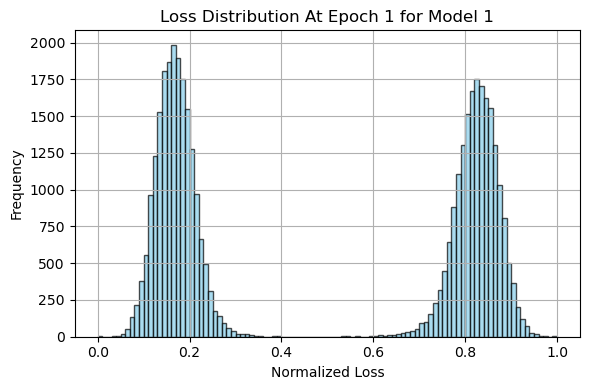

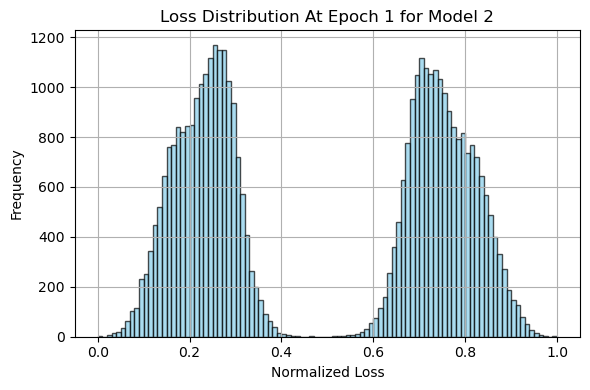

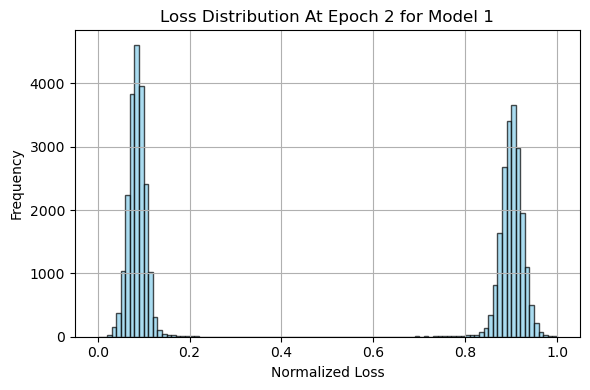

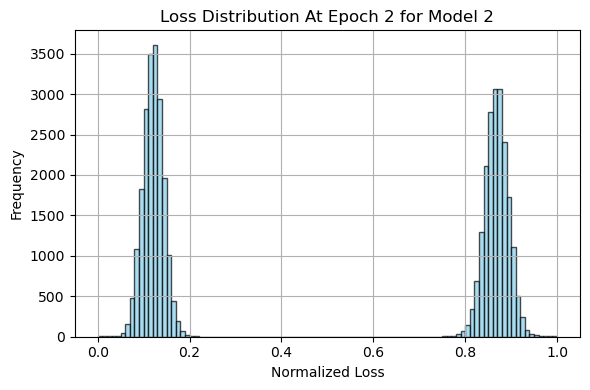

In [21]:
fit_gmm_and_plot_histogram()